In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

fileName = "./data/ModelsResults.xlsx"  # If it's in the current directory
sheetName = "staticOriginalResults"
limit = 15
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"]).iloc[:limit, :]
df

,Model,Compression,ROC_AUC
0,pythia-70M,Original,64.55
1,pythia-70M,8-bit,64.53
2,pythia-70M,4-bit,63.36
3,pythia-160M,Original,65.70
4,pythia-160M,8-bit,65.66
5,pythia-160M,4-bit,64.50
6,pythia-410M,Original,67.41
7,pythia-410M,8-bit,67.40
8,pythia-410M,4-bit,65.67
9,pythia-1B,Original,68.99


In [2]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1.png"):
    # Define consistent styles
    
    model_styles = {
        "pythia-70M": {"color": "#0d8be5", "marker": "o", "linestyle": "-", "dash": None, "label": "P-70M"},
        "pythia-160M": {"color": "#ff7f0e", "marker": "s", "linestyle": "--", "dash": (5, 5), "label": "P-160M"},
        "pythia-410M": {"color": "#2ca02c", "marker": "D", "linestyle": ":", "dash": (1, 1), "label": "P-410M"},
        "pythia-1B": {"color": "#ef1010", "marker": "^", "linestyle": "-.", "dash": (3, 5, 1, 5), "label": "P-1B"},
        "pythia-1.4B": {"color": "#9467bd", "marker": "v", "linestyle": (0, (3, 1, 1, 1)), "dash": None, "label": "P-1.4B"}
    }

    
    # Prepare data
    compression_order = ["Original", "8-bit", "4-bit"]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    # Plot each model separately with explicit styling
    for model, style in model_styles.items():
        if model in df["Model"].unique():
            model_df = df[df["Model"] == model]
            ax.plot(
                model_df["Compression"].cat.codes,  # Use category codes for x-axis
                model_df[score_col],
                label=model.replace("pythia-", "P-"),
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=3,
                markersize=10
            )
    
    # Format x-axis
    ax.set_xticks(range(len(compression_order)))
    ax.set_xticklabels(compression_order)
    ax.set_xticklabels([
    "Original (32-bit)", 
    "8-bit", 
    "4-bit",
], fontsize=25, rotation=0, ha='center')

    # Create legend
    # plt.legend(
    #     loc='upper center',
    #     # title ='Models (P=Pythia)',
    #     # title_fontsize='15',
    #     bbox_to_anchor=(0.5, 1.15),
    #     ncol=5,
    #     fontsize=16,
    #     frameon=True
    # )
    
    # Axis labels and formatting
    plt.ylabel(f"{score_col} Score ({miaName}) (%)", fontsize=30, labelpad=10)
    plt.xlabel("Precision Level", fontsize=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=25)
    plt.grid(True, linestyle='--', alpha=0.4)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}.pdf", dpi=350, bbox_inches="tight")
    plt.show()

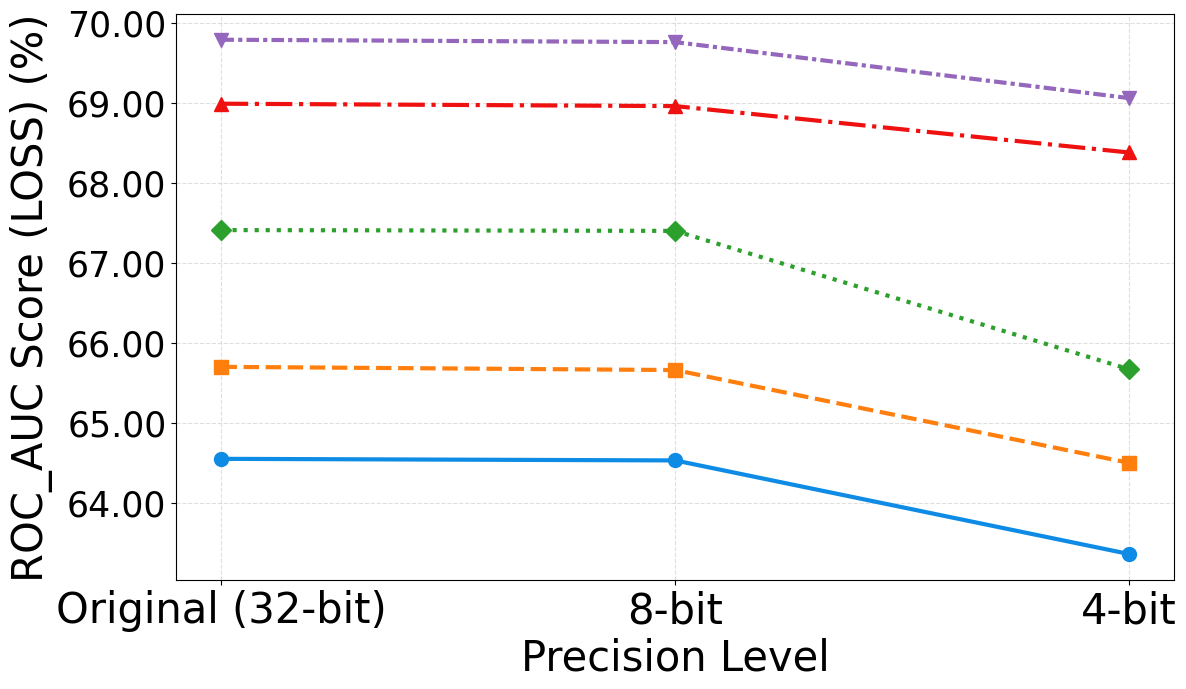

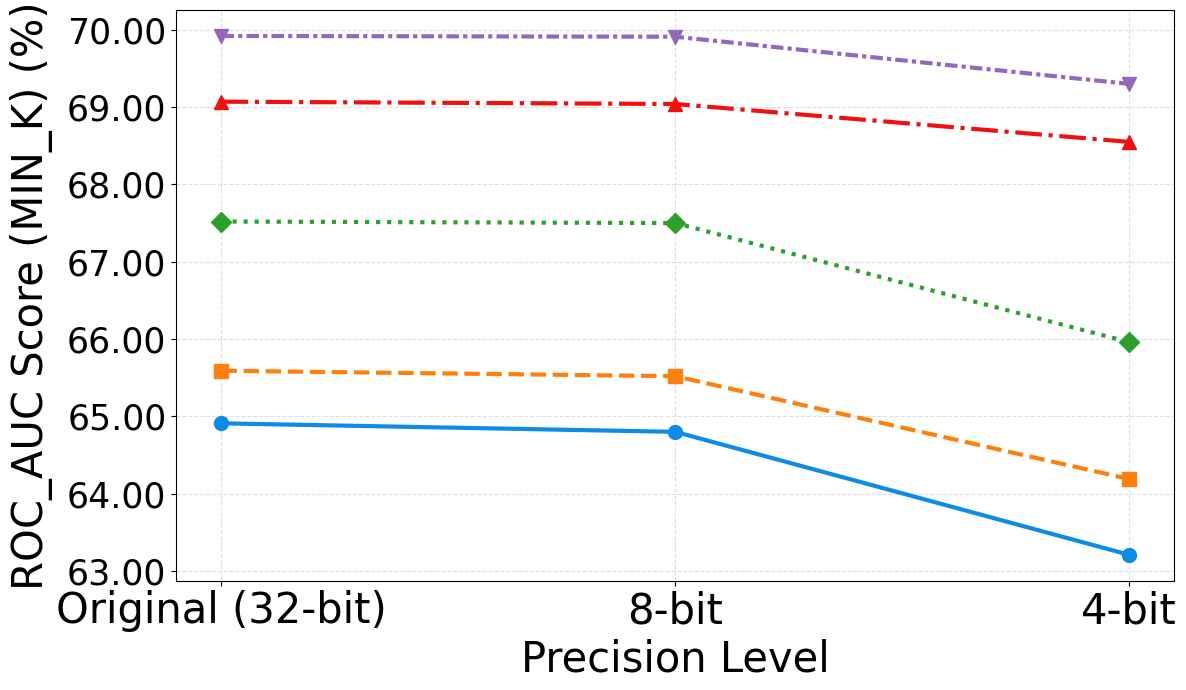

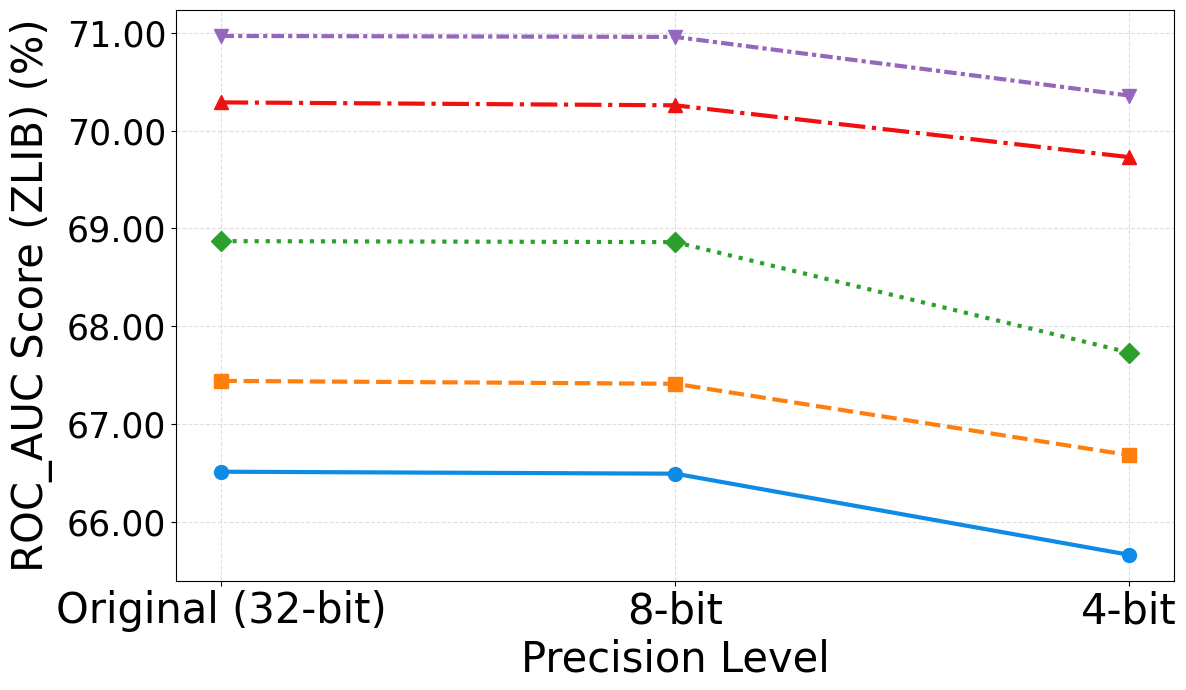

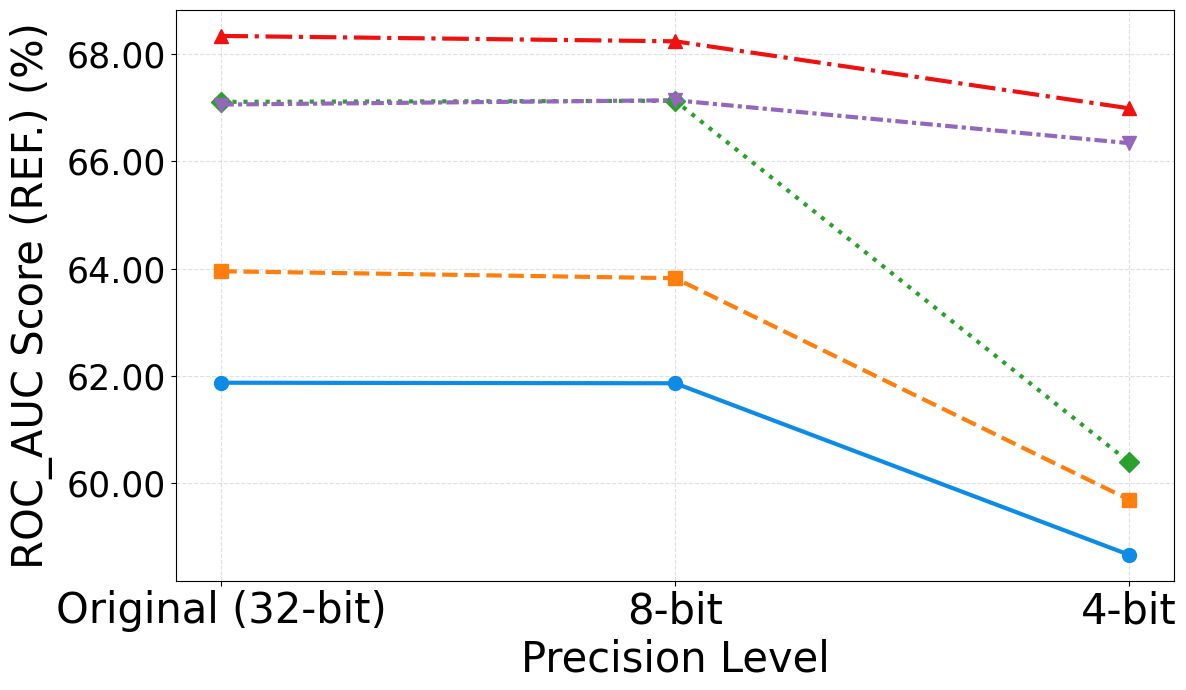

In [3]:
limit = 15
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"]).iloc[:limit, :]
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"]).iloc[:limit, :]
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-2.2")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"]).iloc[:limit, :]
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-2.3")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"]).iloc[:limit, :]
df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-2.4")

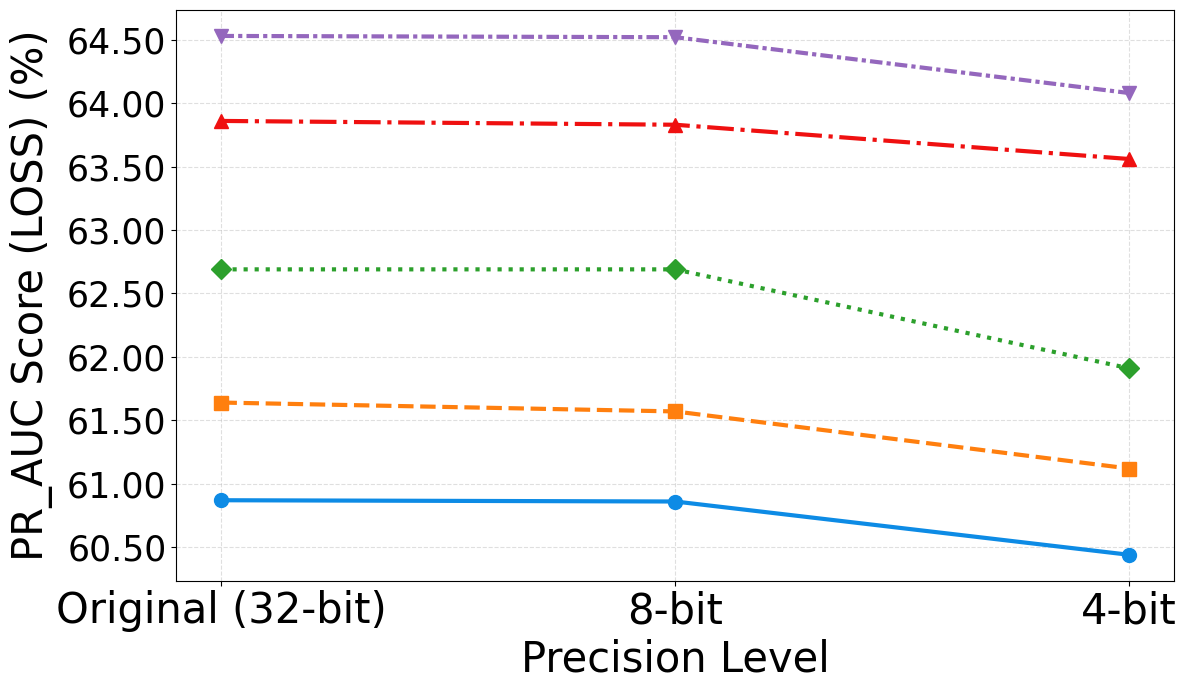

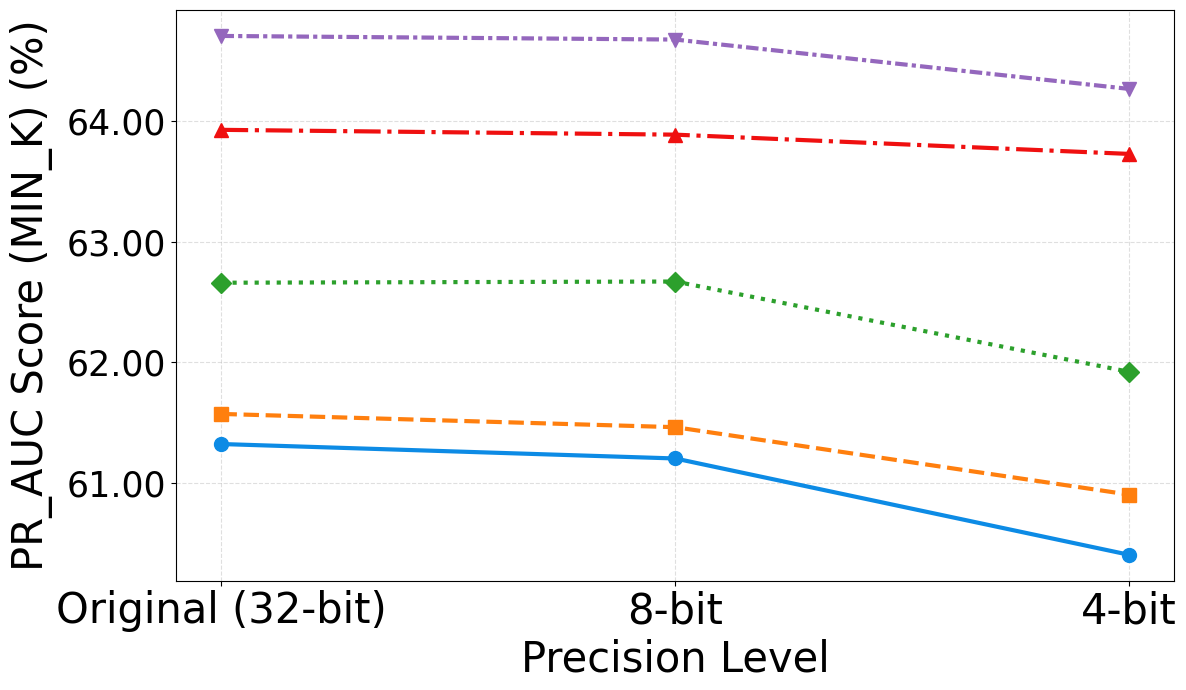

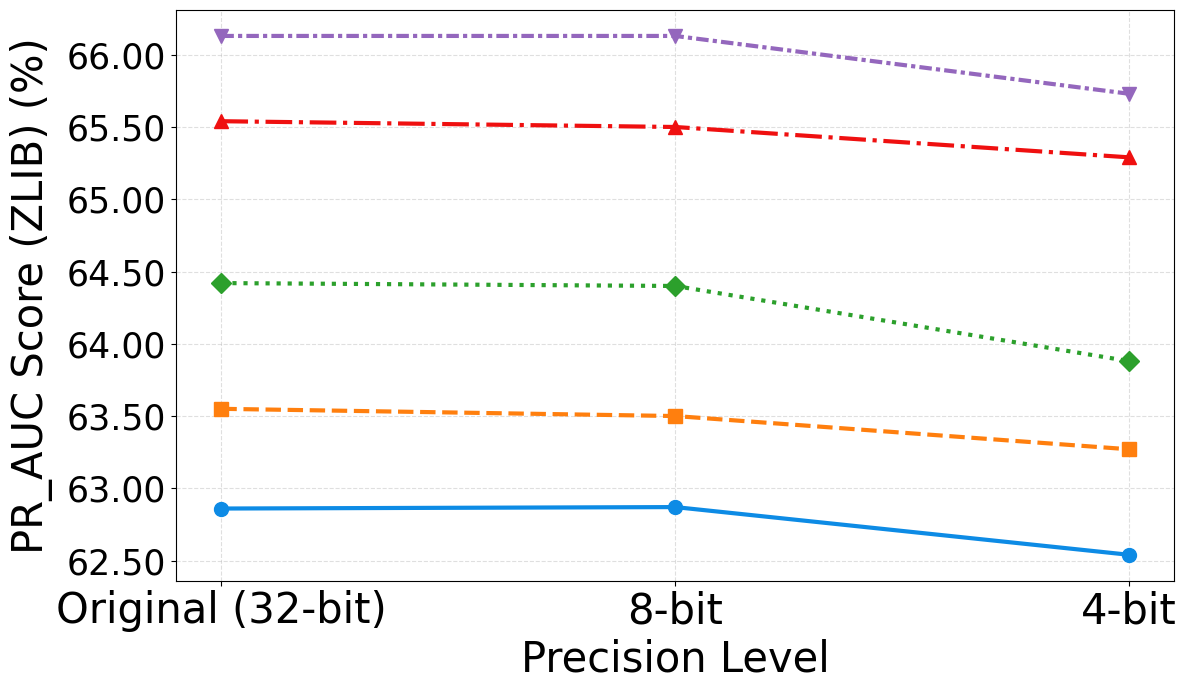

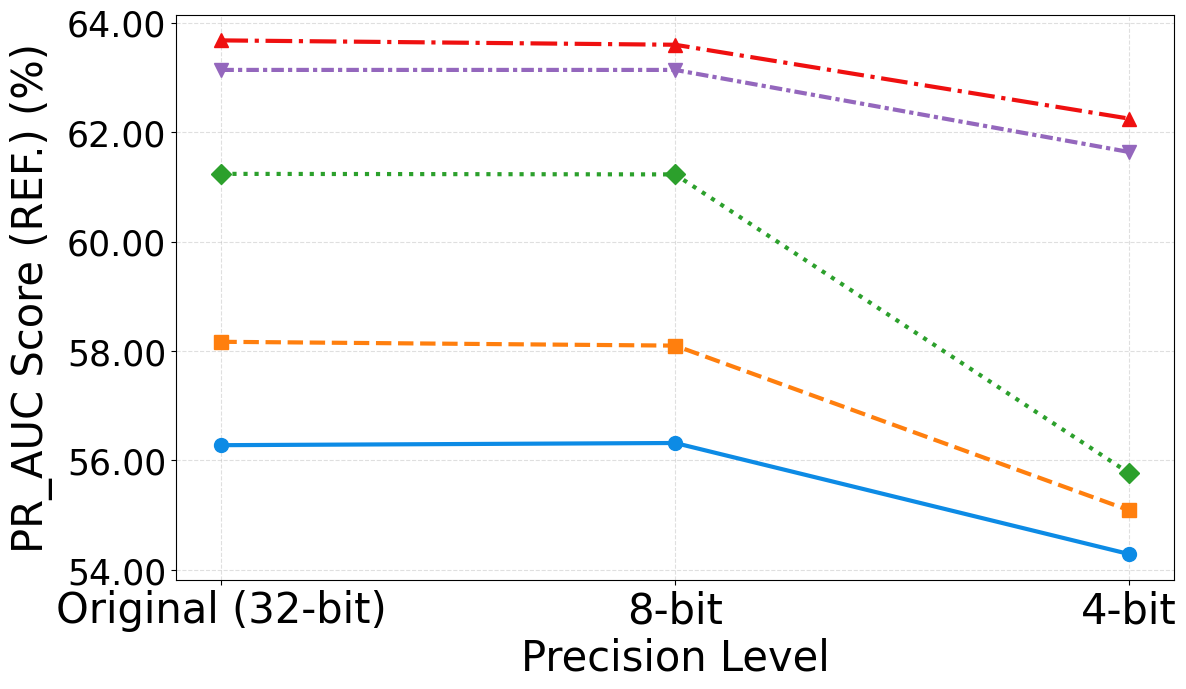

In [5]:
metric = "PR_AUC"

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", metric]).iloc[:limit, :]
graph_roc_auc(df, score_col=metric, miaName="LOSS", fileName="RQ-2.5")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "PR_AUC.1"]).iloc[:limit, :]
df = df.rename(columns={"PR_AUC.1": metric})
graph_roc_auc(df, score_col=metric, miaName="MIN_K", fileName="RQ-2.6")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "PR_AUC.2"]).iloc[:limit, :]
df = df.rename(columns={"PR_AUC.2": metric})
graph_roc_auc(df, score_col=metric, miaName="ZLIB", fileName="RQ-2.7")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "PR_AUC.3"]).iloc[:limit, :]
df = df.rename(columns={"PR_AUC.3": metric})
graph_roc_auc(df, score_col=metric, miaName="REF.", fileName="RQ-2.8")

## second part

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_82478/1041790297.py:15: FutureWarning: The provided callable <function mean at 0x1062ec670> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


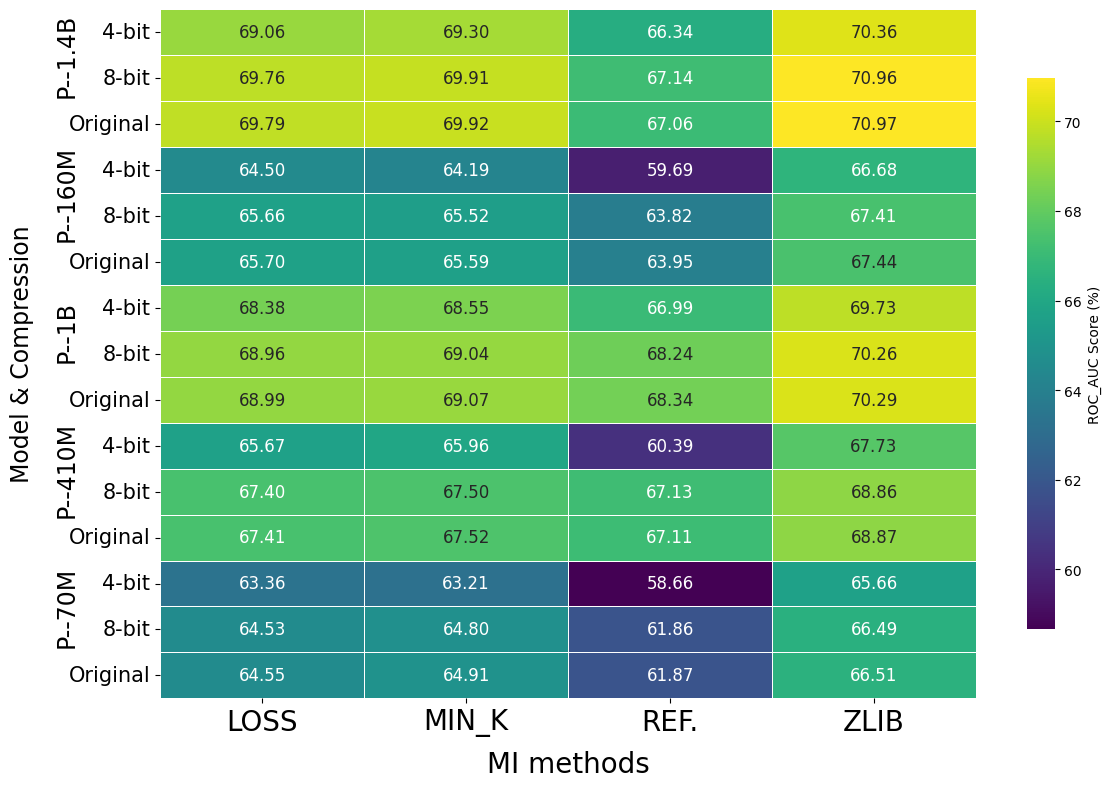

In [6]:
# Data preparation (unchanged)
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]).iloc[:limit, :]
df.rename(columns={"ROC_AUC": "LOSS", "ROC_AUC.1": "MIN_K", "ROC_AUC.2": "ZLIB", "ROC_AUC.3": "REF."}, inplace=True)
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF.']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

# Create long format and pivot table (unchanged)
df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# ==== Enhanced Plotting ====
plt.figure(figsize=(12, 8))  # Slightly larger figure
ax = plt.gca()

# 1. Improved Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='viridis',  # More perceptually uniform colormap
    fmt='.2f', 
    cbar_kws={'label': 'ROC_AUC Score (%)', 'shrink': 0.8},
    linewidths=0.5,  # Add grid lines between cells
    linecolor='white',  # White grid lines
    annot_kws={'fontsize': 12},  # Larger annotation text
    ax=ax
)

# 2. Enhanced Axis Labels
ax.set_xlabel("MI methods", fontsize=20, labelpad=10)
ax.set_ylabel("")  # Remove default y-label

# 3. Improved Y-axis ticks (compression labels)
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(
    compression_labels, 
    rotation=0, 
    fontsize=15,
    va='center'  # Better vertical alignment
)

# 4. Model Group Labels with Better Formatting
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()
renamed_models = [model.replace("pythia", "P-") for model in unique_models]  # More readable prefix

row_counts = models.value_counts().sort_index()
start_idx = 0
for model, r_model in zip(unique_models, renamed_models):
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5
    ax.text(
        -0.4, center_row, r_model,  # Moved slightly further left
        rotation=90,  # Horizontal text for better readability
        va='center', 
        ha='right',
        fontsize=17, 
        color='black',
        # fontweight='bold'  # Emphasize model names
    )
    start_idx += count

# 5. Final Adjustments
plt.xticks(rotation=0, ha='center', fontsize=20)  # Diagonal x-labels for better fit
# plt.title("Model Vulnerability to MIA Attacks by Compression Type", pad=20, fontsize=16)
plt.ylabel("Model & Compression", labelpad=25, fontsize=17)

# Add subtle grid for better value comparison
ax.hlines(range(len(pivot_df)), *ax.get_xlim(), colors='white', linewidths=0.5)

plt.tight_layout()
plt.savefig("./output/roc_auc_heatmap.pdf", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_82478/1906644719.py:15: FutureWarning: The provided callable <function mean at 0x1062ec670> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


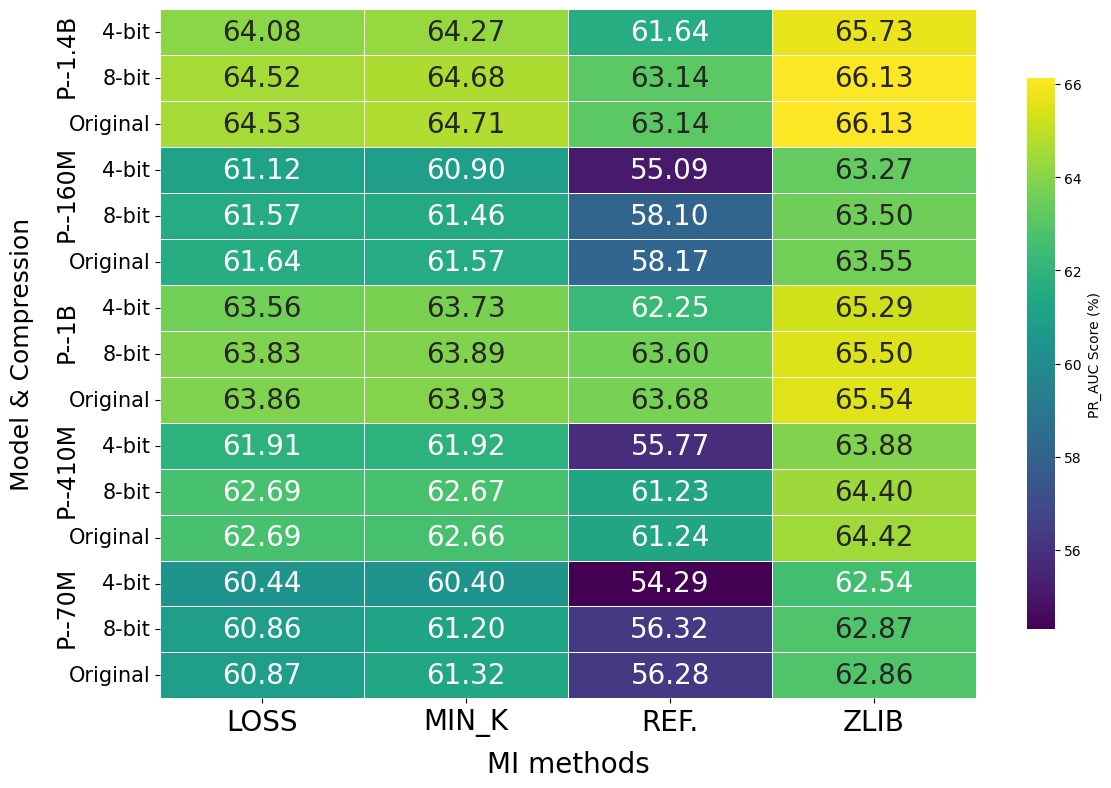

In [7]:
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]).iloc[:limit, :]
df.rename(columns={"PR_AUC": "LOSS", "PR_AUC.1": "MIN_K", "PR_AUC.2": "ZLIB", "PR_AUC.3": "REF."}, inplace=True)
# Data preparation (unchanged)
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF.']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

# Create long format and pivot table (unchanged)
df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# ==== Enhanced Plotting ====
plt.figure(figsize=(12, 8))  # Slightly larger figure
ax = plt.gca()

# 1. Improved Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='viridis',  # More perceptually uniform colormap
    fmt='.2f', 
    cbar_kws={'label': 'PR_AUC Score (%)', 'shrink': 0.8},
    linewidths=0.5,  # Add grid lines between cells
    linecolor='white',  # White grid lines
    annot_kws={'fontsize': 20},  # Larger annotation text
    ax=ax
)

# 2. Enhanced Axis Labels
ax.set_xlabel("MI methods", fontsize=20, labelpad=10)
ax.set_ylabel("")  # Remove default y-label

# 3. Improved Y-axis ticks (compression labels)
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(
    compression_labels, 
    rotation=0, 
    fontsize=15,
    va='center'  # Better vertical alignment
)

# 4. Model Group Labels with Better Formatting
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()
renamed_models = [model.replace("pythia", "P-") for model in unique_models]  # More readable prefix

row_counts = models.value_counts().sort_index()
start_idx = 0
for model, r_model in zip(unique_models, renamed_models):
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5
    ax.text(
        -0.4, center_row, r_model,  # Moved slightly further left
        rotation=90,  # Horizontal text for better readability
        va='center', 
        ha='right',
        fontsize=17, 
        color='black',
        # fontweight='bold'  # Emphasize model names
    )
    start_idx += count

# 5. Final Adjustments
plt.xticks(rotation=0, ha='center', fontsize=20)  # Diagonal x-labels for better fit
# plt.title("Model Vulnerability to MIA Attacks by Compression Type", pad=20, fontsize=16)
plt.ylabel("Model & Compression", labelpad=25, fontsize=18)

# Add subtle grid for better value comparison
ax.hlines(range(len(pivot_df)), *ax.get_xlim(), colors='white', linewidths=0.5)

plt.tight_layout()
plt.savefig("./output/pr_auc_heatmap.pdf", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()